# Práctico 1: Análisis y Visualización

**Se espera que:**
* Analicen las distribuciones de los elementos para
distintas clases de tejido.
* Exploren correlaciones entre elementos y posibles
perfiles químicos característicos.
* Realicen visualizaciones claras y efectivas, tanto
estadísticas como espaciales (por ejemplo, mapas de
concentración elemental).

**Algunas preguntas**
* ¿Qué elementos químicos presentan mayor presencia o
variabilidad en los diferentes tipos de tejido?
* ¿Existen combinaciones elementales características
asociadas a tipos específicos de tejido?
* ¿Qué correlaciones o patrones de co-ocurrencia existen
entre los distintos elementos?
* ¿La dieta de los ratones tiene un efecto observable sobre
la composición elemental de los tumores?

In [169]:
!git clone https://github.com/JeroFotinos/hist_via_cluster.git

fatal: destination path 'hist_via_cluster' already exists and is not an empty directory.


In [170]:
import os
os.chdir('/content/hist_via_cluster')

import sys
sys.path.append('/content/hist_via_cluster')

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
# From the repository of the dataset, we import the function that
# loads the fluorescence dataset
from src.load_dataset import load_fluorescence

# Cargar dataset

In [171]:
fluorescence = load_fluorescence('data',as_frame=True)
df = fluorescence.frame

# Mapear nombres legibles
df['label_name'] = df.label.replace(fluorescence.label_map)
df['diet_name'] = df.diet.replace(fluorescence.diet_map)

# Revision general

In [172]:
# Informacion general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175211 entries, 0 to 175210
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   diet        175211 non-null  category
 1   mouse       175211 non-null  int64   
 2   take        175211 non-null  int64   
 3   row         175211 non-null  int64   
 4   col         175211 non-null  int64   
 5   Ca          175211 non-null  float64 
 6   Cu          175211 non-null  float64 
 7   Fe          175211 non-null  float64 
 8   K           175211 non-null  float64 
 9   Mn          175211 non-null  float64 
 10  P           175211 non-null  float64 
 11  S           175211 non-null  float64 
 12  Zn          175211 non-null  float64 
 13  label       23003 non-null   category
 14  label_name  23003 non-null   category
 15  diet_name   175211 non-null  category
dtypes: category(4), float64(8), int64(4)
memory usage: 16.7 MB


In [173]:
# Estadísticas descriptivas del dataframe de cada columna
df.describe()

,mouse,take,row,col,Ca,Cu,Fe,K,Mn,P,S,Zn
count,175211.000000,175211.000000,175211.000000,175211.000000,1.752110e+05,1.752110e+05,1.752110e+05,1.752110e+05,1.752110e+05,1.752110e+05,1.752110e+05,1.752110e+05
mean,17.427559,0.106540,41.100741,40.680973,1.375511e+09,7.559693e+06,1.300203e+08,7.021223e+06,2.011924e+07,6.744482e+06,2.738555e+07,6.989112e+07
std,11.459746,0.308529,28.058009,28.110678,1.504605e+09,9.586318e+06,1.804093e+08,1.617595e+07,3.362677e+07,1.659421e+07,4.814614e+07,9.473747e+07
min,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.000000,0.000000,18.000000,18.000000,5.184645e+08,5.164515e+05,4.481730e+07,0.000000e+00,4.684340e+06,0.000000e+00,0.000000e+00,2.482850e+07
50%,15.000000,0.000000,37.000000,36.000000,8.743000e+08,5.114860e+06,7.804350e+07,0.000000e+00,1.026760e+07,0.000000e+00,1.277800e+07,4.565720e+07
75%,28.000000,0.000000,61.000000,60.000000,1.653060e+09,1.061500e+07,1.295140e+08,8.618140e+06,1.793230e+07,7.250180e+06,3.291800e+07,7.712515e+07
max,39.000000,1.000000,117.000000,120.000000,1.159470e+10,1.778380e+08,6.922760e+09,4.589360e+08,2.994300e+08,3.002360e+08,6.180620e+08,1.513270e+09


In [174]:
# Datos únicos por columna
a=df['take'].unique()
print(f'numero de dietas unicas: {df.diet_name.unique()}')
print(f'numero de ratones unicos: {df.mouse.unique()}')
print(f'numero de tomas unicas: {a}')
print(f'numero de etiquetas unicas: {df.label_name.unique()}')

numero de dietas unicas: ['omega3', 'control', 'omega6']
Categories (3, object): ['control', 'omega3', 'omega6']
numero de ratones unicos: [30 37 27 31 39 29 38 33 32 35 28 36  1 11 12  8  4  6 10  7  9  2 19 15
 18 14 17 16 21 23 25 20 26]
numero de tomas unicas: [0 1]
numero de etiquetas unicas: [NaN, 'loose connective tissue', 'no label', 'tumoral B', 'tumoral A', ..., 'paraffin', 'blood', 'no sample', 'dense connective tissue', 'tumoral C']
Length: 11
Categories (10, object): ['no label', 'tumoral A', 'tumoral B', 'tumoral C', ...,
                          'loose connective tissue', 'no sample', 'dense connective tissue', 'paraffin']


In [175]:
print("Cantidad de valores nulos (NaN) por columna:")
print(df.isnull().sum())

print("\nCantidad de valores cero por columna de fluorescencia:")
fluorescence_cols = ['Ca', 'Cu', 'Fe', 'K', 'Mn', 'P', 'S', 'Zn']
for col in fluorescence_cols:
    zero_count = (df[col] == 0).sum()
    print(f"- {col}: {zero_count}")

print("\nVerificando valores negativos en columnas de fluorescencia:")
negative_values_found = False
for col in fluorescence_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"- ¡Atención! Se encontraron {negative_count} valores negativos en la columna '{col}'.")
        negative_values_found = True

if not negative_values_found:
    print("No se encontraron valores negativos en las columnas de fluorescencia.")

Cantidad de valores nulos (NaN) por columna:
diet               0
mouse              0
take               0
row                0
col                0
Ca                 0
Cu                 0
Fe                 0
K                  0
Mn                 0
P                  0
S                  0
Zn                 0
label         152208
label_name    152208
diet_name          0
dtype: int64

Cantidad de valores cero por columna de fluorescencia:
- Ca: 18
- Cu: 40210
- Fe: 783
- K: 119257
- Mn: 22779
- P: 102985
- S: 57251
- Zn: 11770

Verificando valores negativos en columnas de fluorescencia:
No se encontraron valores negativos en las columnas de fluorescencia.


<Axes: >

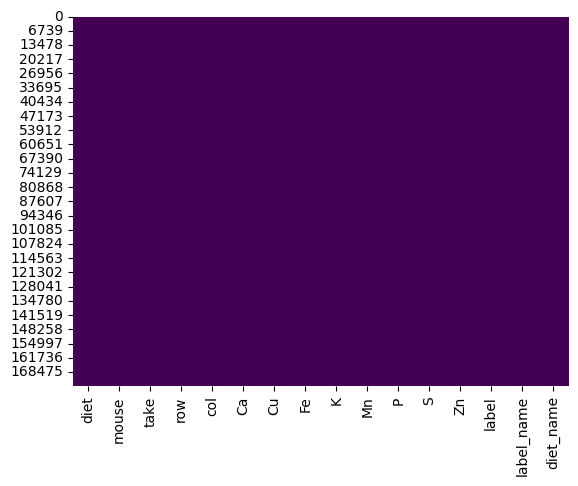

In [176]:
sns.heatmap(df==None, cbar=False, cmap='viridis')

<Axes: >

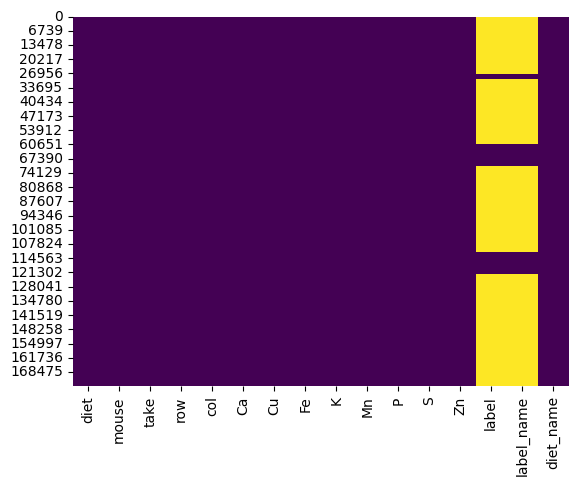

In [177]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

<Axes: >

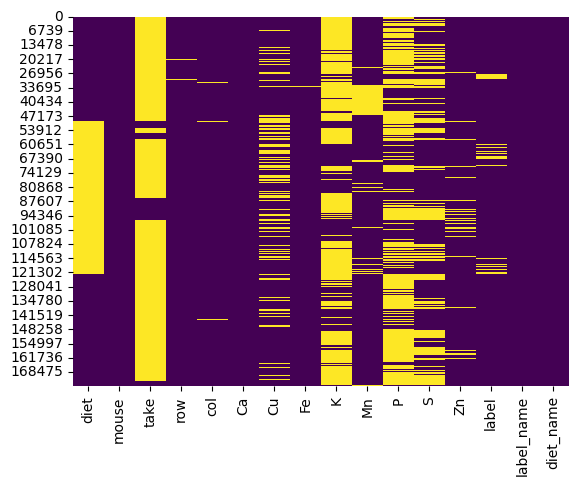

In [178]:
sns.heatmap(df==0, cbar=False, cmap='viridis')

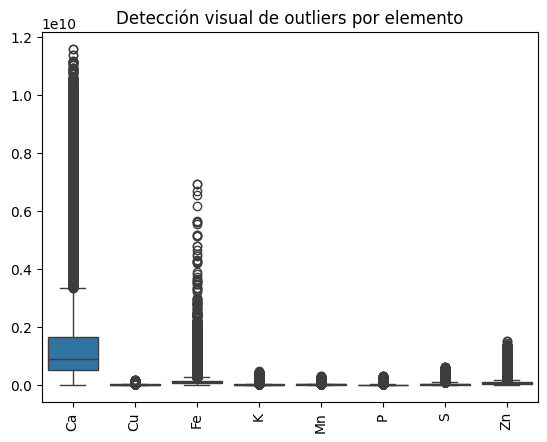

In [179]:
# Verificacion visual de outliers
sns.boxplot(data=df[fluorescence.element_order])
plt.xticks(rotation=90)
plt.title("Detección visual de outliers por elemento")
plt.show()

# Dieta vs Elementos

Pudimos observar que el dataframe contiene valores cero en las columnas de fluorescencia de los elementos químicos.

Dado que los valores cero en la fluorescencia no aportan información relevante para nuestro análisis, decidimos eliminarlos de las columnas correspondientes a los elementos químicos. Para ello, crearemos subconjuntos del dataframe original, filtrando cada elemento individualmente para excluir las filas con valor cero en su respectiva columna de fluorescencia.

In [180]:
# Todos los datos (sin filtrar labels)
df_dieta = df.copy()

## Boxplots y KDE

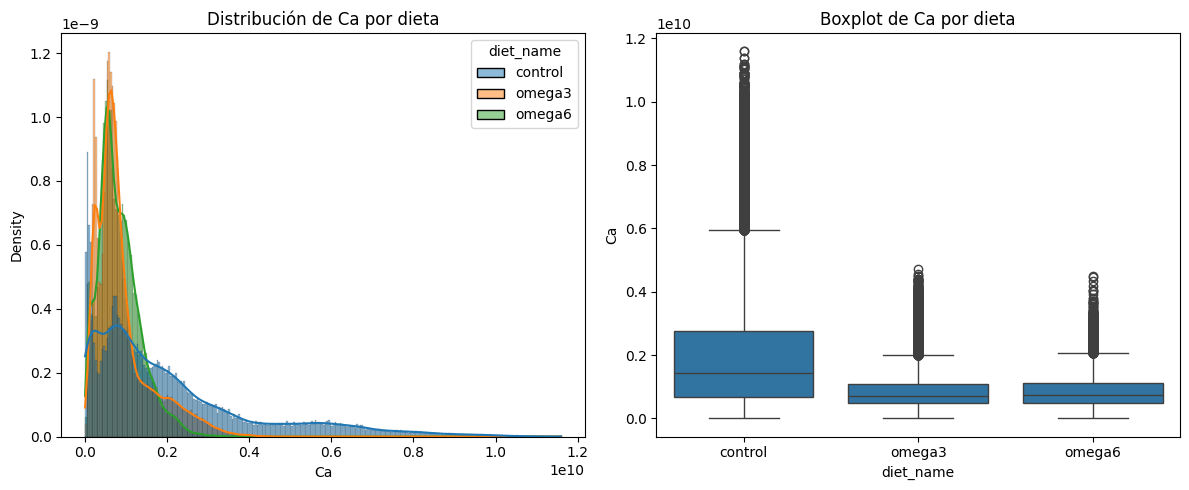

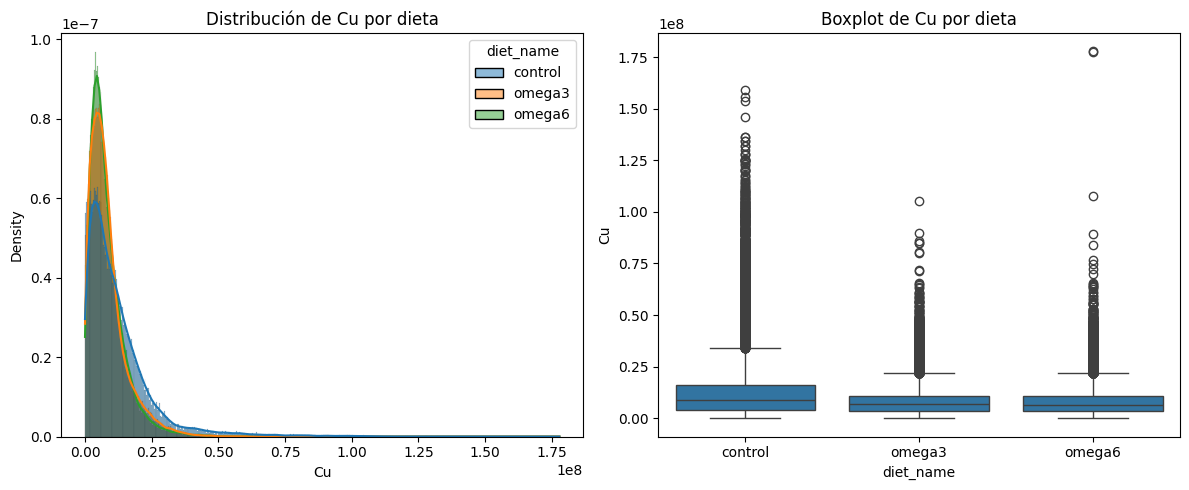

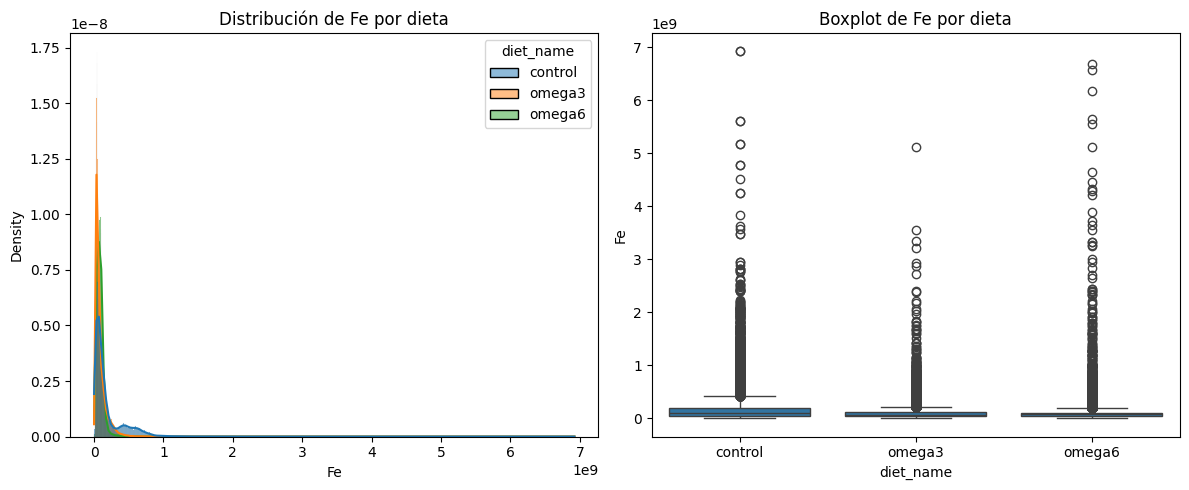

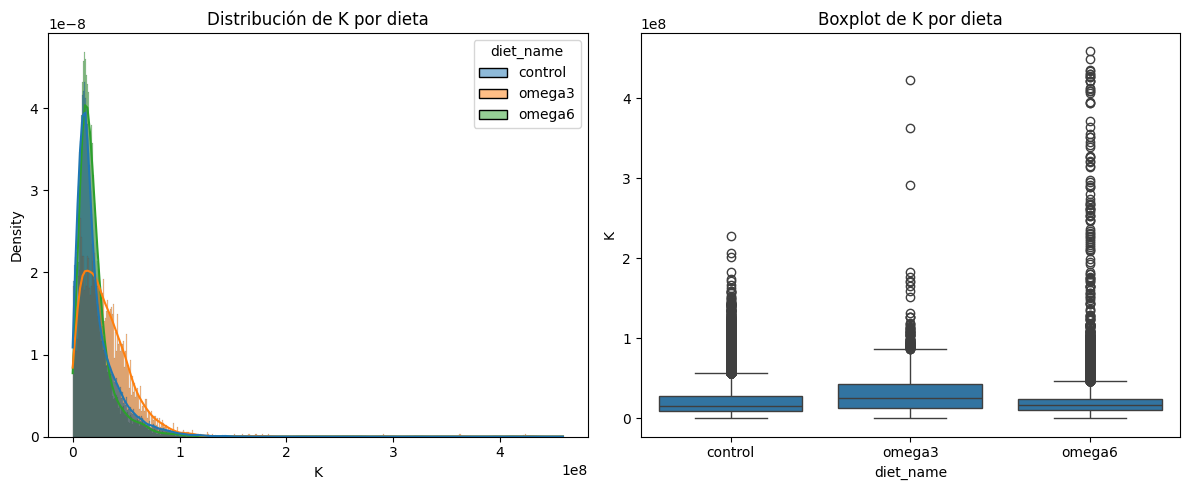

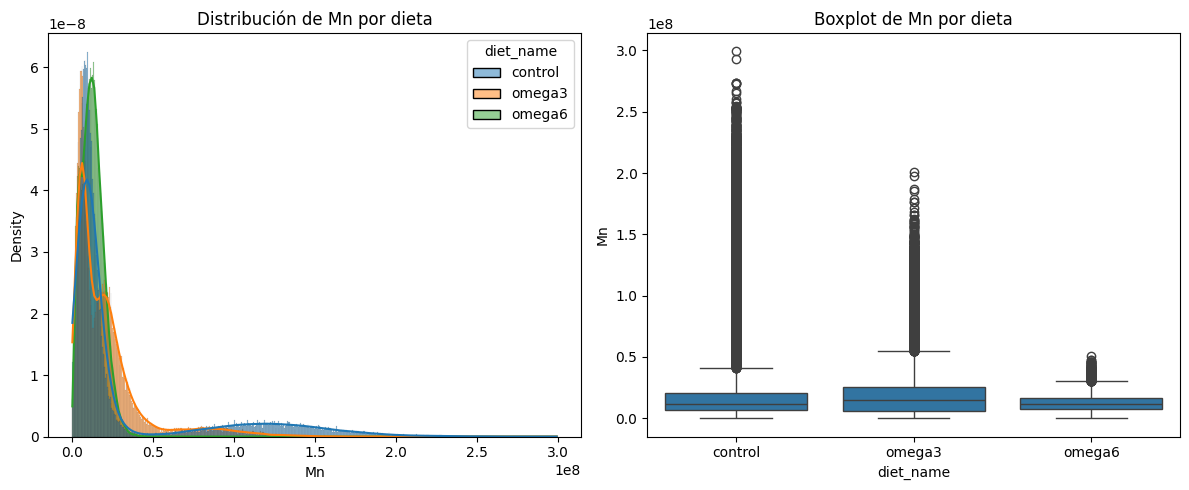

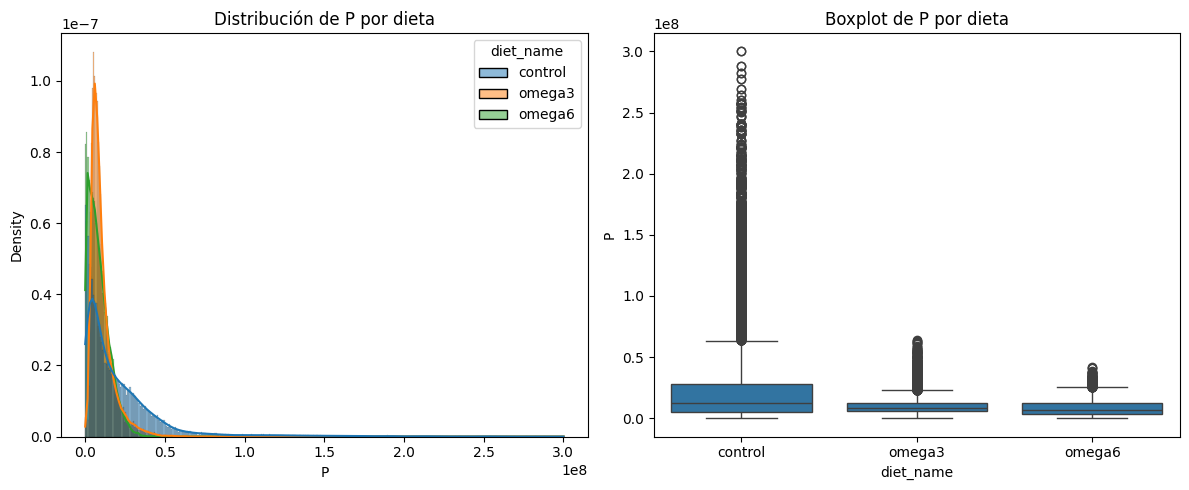

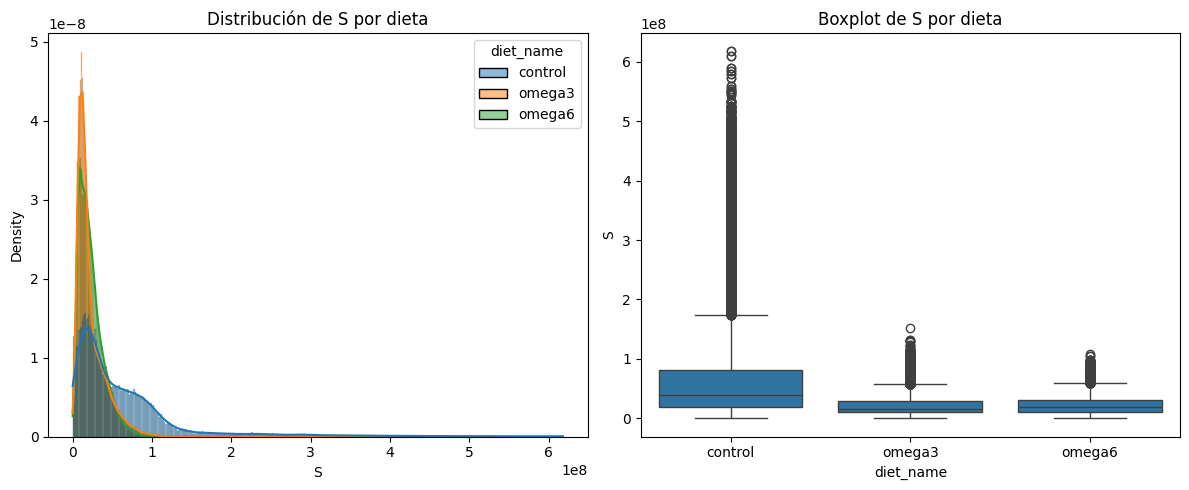

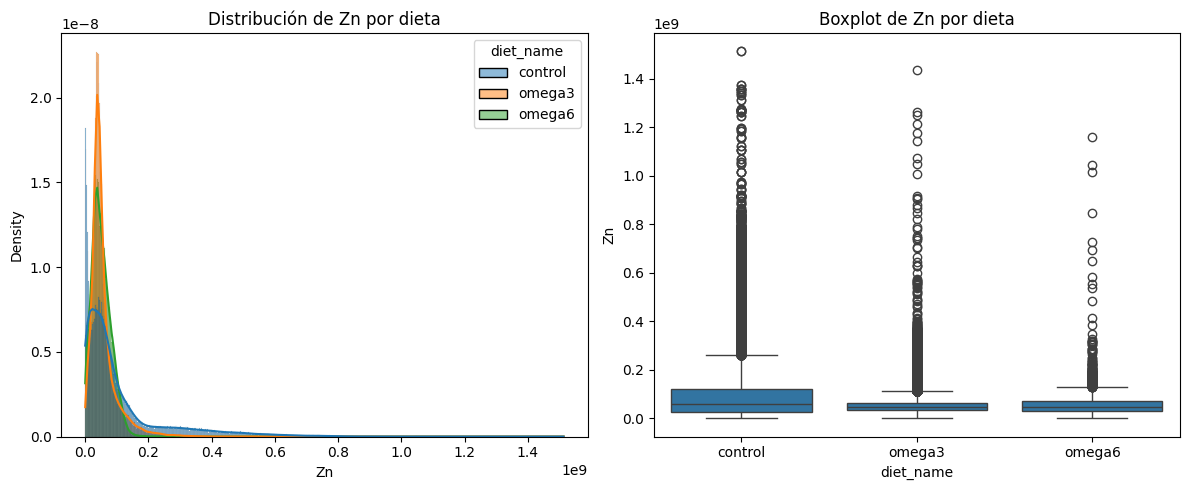

In [181]:
# Distribución y boxplots por dieta
for var in fluorescence_cols:
    plt.figure(figsize=(12, 5))

    # KDE por dieta
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_dieta[df_dieta[var] > 0],
                 x=var, hue='diet_name', kde=True,
                 stat='density', common_norm=False)
    plt.title(f'Distribución de {var} por dieta')

    # Boxplot por dieta
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_dieta[df_dieta[var] > 0],
                x='diet_name', y=var)
    plt.title(f'Boxplot de {var} por dieta')

    plt.tight_layout()
    plt.savefig(f'results/plots_dieta/{var}_dieta.png')
    plt.show()

Tanto los boxplots como los graficos KDE muestran visualmente diferencias en las distribuciones de fluorescencia para varios elementos entre los grupos dietarios (omega3, omega6, control). Al parecer la dieta tiene un efecto en la composicion elemental.

## Fluorescencia media

In [182]:
df_dieta = df[(df[fluorescence_cols] > 0).any(axis=1)].copy()

                     Ca            Cu            Fe             K  \
diet_name                                                           
control    2.081121e+09  8.468964e+06  1.854890e+08  1.001363e+07   
omega3     9.125192e+08  7.197130e+06  9.277034e+07  2.321818e+06   
omega6     8.461151e+08  6.662354e+06  8.920150e+07  7.311514e+06   

                     Mn             P             S            Zn  
diet_name                                                          
control    2.982693e+07  1.220818e+07  4.647383e+07  9.531675e+07  
omega3     1.457697e+07  3.800355e+06  1.493141e+07  5.524836e+07  
omega6     1.206946e+07  2.050211e+06  1.299568e+07  4.893051e+07  


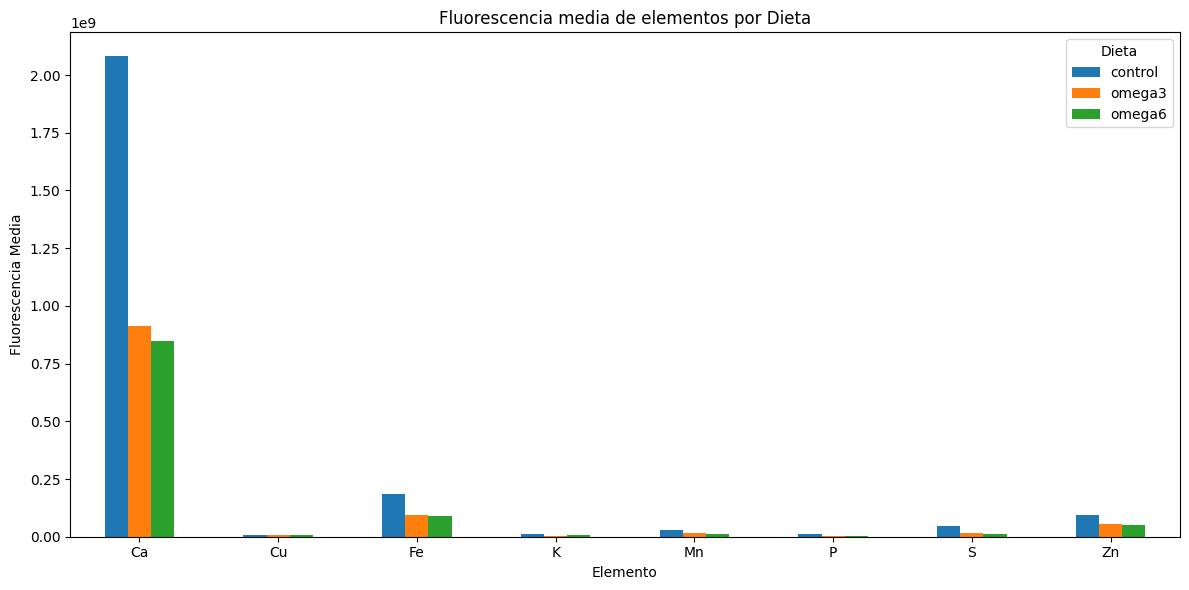

In [183]:
# Calcular la fluorescencia media por dieta
mean_fluorescence_by_diet = df_dieta.groupby('diet_name')[fluorescence_cols].mean()
print(mean_fluorescence_by_diet)

# Visualizar
mean_fluorescence_by_diet.T.plot(kind='bar', figsize=(12, 6))
plt.title('Fluorescencia media de elementos por Dieta')
plt.xlabel('Elemento')
plt.ylabel('Fluorescencia Media')
plt.xticks(rotation=0)
plt.legend(title='Dieta')
plt.tight_layout()
plt.show()


Los elementos con mayor presencia promedio son:
* Calcio: predomina en la dieta control, seguidamente de omega3 y omega6
* Hierro: idem calcio
* Zinc: idem calcio
* Azufre: idem calcio

## Mapa de correlacion

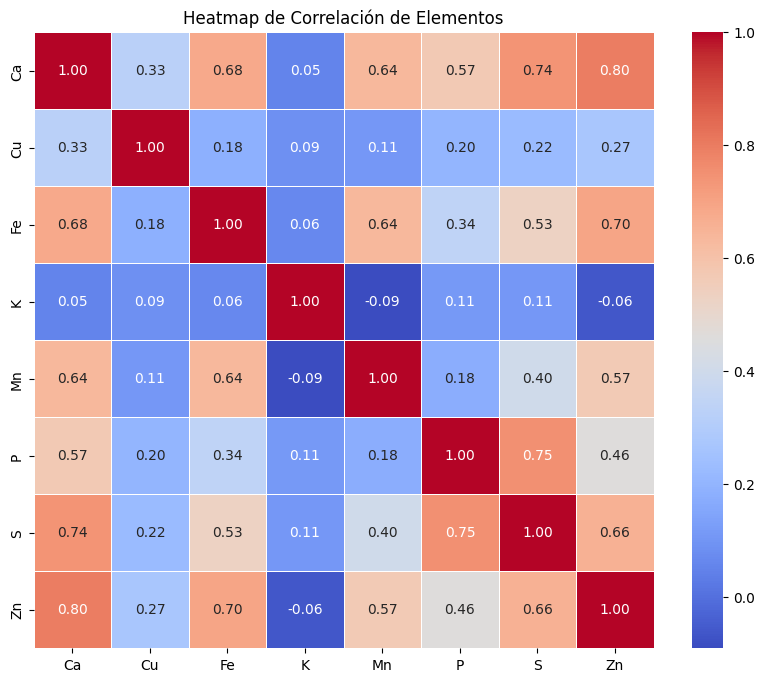

In [184]:
# Calcular la matriz de correlación para las columnas de fluorescencia
correlation_matrix = df_dieta[fluorescence_cols].corr()

# Crear el heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlación de Elementos')
plt.show()

Se observan correlaciones positivas importantes entre:
* Ca y Zn: 0.80
* P y S: 0.75
* Ca y S: 0.74
* Fe y Zn: 0.70
* Ca y Fe: 0.68
* S y Zn: 0.66
* Ca y Mn: 0.64
* Fe y Mn: 0.64
* Ca y P: 0.57
* Mn y Zn: 0.57

## Prueba de hipotesis

In [185]:
# Pruebas t-test entre dietas
alpha = 0.05
for var in fluorescence_cols:
    grupos = [df_dieta[df_dieta['diet_name'] == d][var]
              for d in df_dieta['diet_name'].unique()]
    dietas = df_dieta['diet_name'].unique()
    print(f"\nT-tests para {var} por dieta:")
    for i in range(len(grupos)):
        for j in range(i + 1, len(grupos)):
            stat, pval = stats.ttest_ind(grupos[i], grupos[j], equal_var=False)
            res = "Rechaza H0" if pval < alpha else "No rechaza H0"
            print(f"{dietas[i]} vs {dietas[j]}: t={stat:.3f}, p={pval:.3e} → {res}")


T-tests para Ca por dieta:
omega3 vs control: t=-143.320, p=0.000e+00 → Rechaza H0
omega3 vs omega6: t=17.308, p=5.310e-67 → Rechaza H0
control vs omega6: t=157.587, p=0.000e+00 → Rechaza H0

T-tests para Cu por dieta:
omega3 vs control: t=-22.757, p=2.146e-114 → Rechaza H0
omega3 vs omega6: t=12.126, p=8.111e-34 → Rechaza H0
control vs omega6: t=33.166, p=4.250e-240 → Rechaza H0

T-tests para Fe por dieta:
omega3 vs control: t=-93.576, p=0.000e+00 → Rechaza H0
omega3 vs omega6: t=5.000, p=5.753e-07 → Rechaza H0
control vs omega6: t=94.513, p=0.000e+00 → Rechaza H0

T-tests para K por dieta:
omega3 vs control: t=-96.842, p=0.000e+00 → Rechaza H0
omega3 vs omega6: t=-54.813, p=0.000e+00 → Rechaza H0
control vs omega6: t=26.831, p=4.478e-158 → Rechaza H0

T-tests para Mn por dieta:
omega3 vs control: t=-76.308, p=0.000e+00 → Rechaza H0
omega3 vs omega6: t=24.943, p=1.304e-136 → Rechaza H0
control vs omega6: t=99.887, p=0.000e+00 → Rechaza H0

T-tests para P por dieta:
omega3 vs control:

Se confirma con la prueba t-student las diferencias entre dietas. Para todos los elementos de fluorescencia, rechazamos la hipotesis nula, lo que indica que hay diferencias significativas en la fluorescencia media de esos elementos.
Esto estaria sugiriendo que la dieta que recibieron los ratones tiene un efecto claro sobre la bioacumulacion o distribucion de Ca, Cu, Fe, K, Mn, P, S y Zn, potencialmente a traves de mecanismos de absorcion, metabolismo o interaccion con tejidos especificos..

# Tejidos vs Elementos

In [186]:
print(fluorescence.label_map)

{0: 'no label', 1: 'necrotic tissue', 2: 'tumoral A', 3: 'tumoral B', 4: 'tumoral C', 5: 'artifacts', 6: 'blood', 7: 'loose connective tissue', 8: 'no sample', 9: 'dense connective tissue', 10: 'paraffin'}


Vamos a escoger las siguientes etiquetas para analizar porque creemos que estan relacionadas a posibles anomalias en el analisis histologico.
- 0: 'no-label' -- DESCARTADA
- 1: 'necrotic tissue' -- NO TIENE DATOS
- 2: 'tumoral A'
- 3: 'tumoral B'
- 4: 'tumoral C'
- 5: 'artifacts' -- DESCARTADA
- 6: 'blood'
- 7: 'loose connective tissue'
- 8: 'no sample' -- DESCARTADA
- 9: 'dense connective tissue'
- 10: 'paraffin' -- DESCARTADA


In [187]:
labels_interesting=['necrotic tissue', 'tumoral A','tumoral B','tumoral C','blood','loose connective tissue','dense connective tissue']

In [188]:
# Filtrar solo etiquetas de interes
df_tejido = df[df['label_name'].isin(labels_interesting)].copy()

## Boxplots y KDE

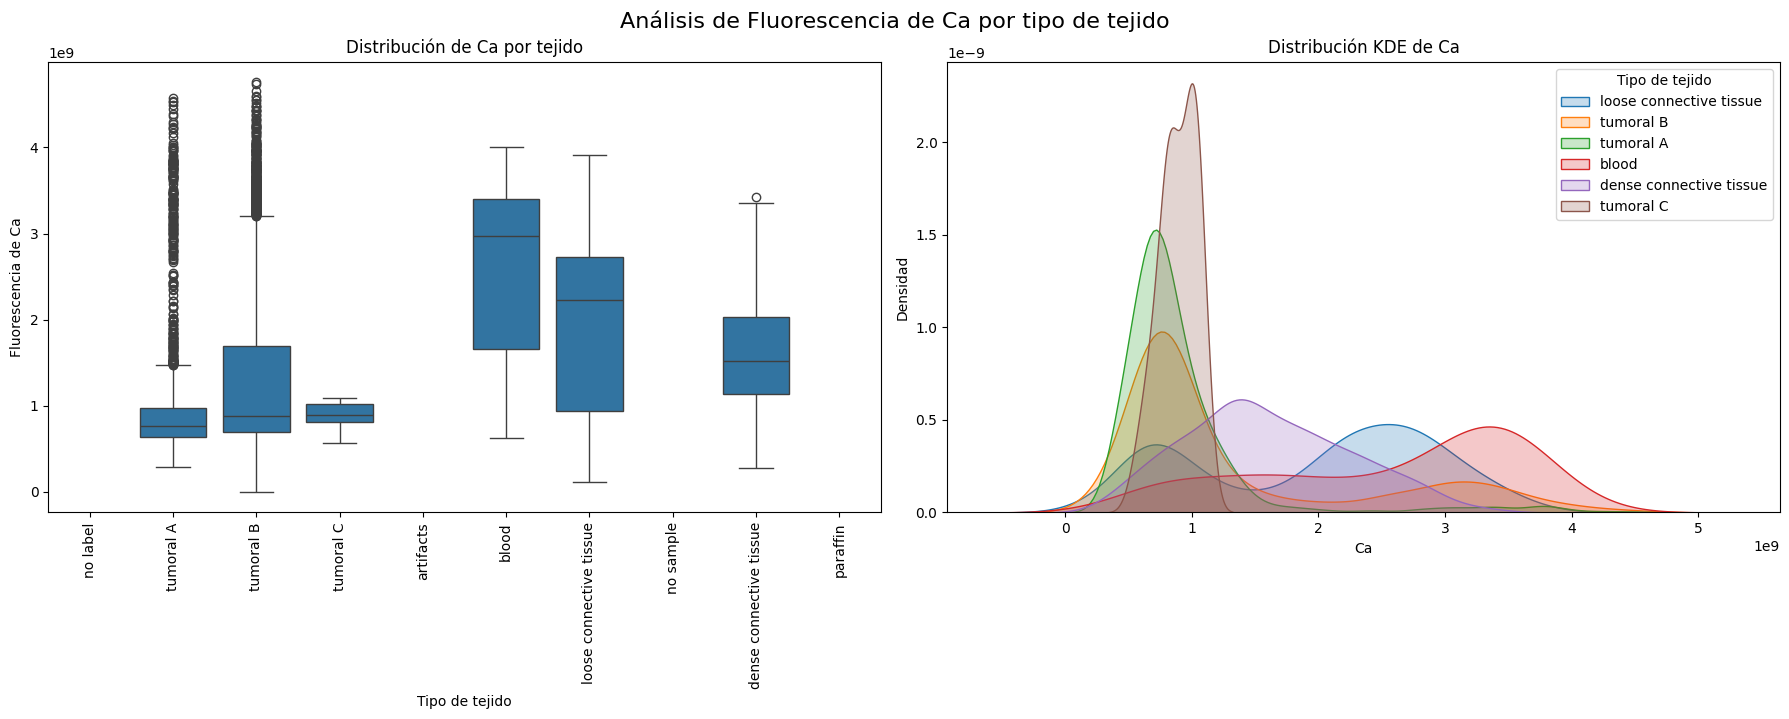

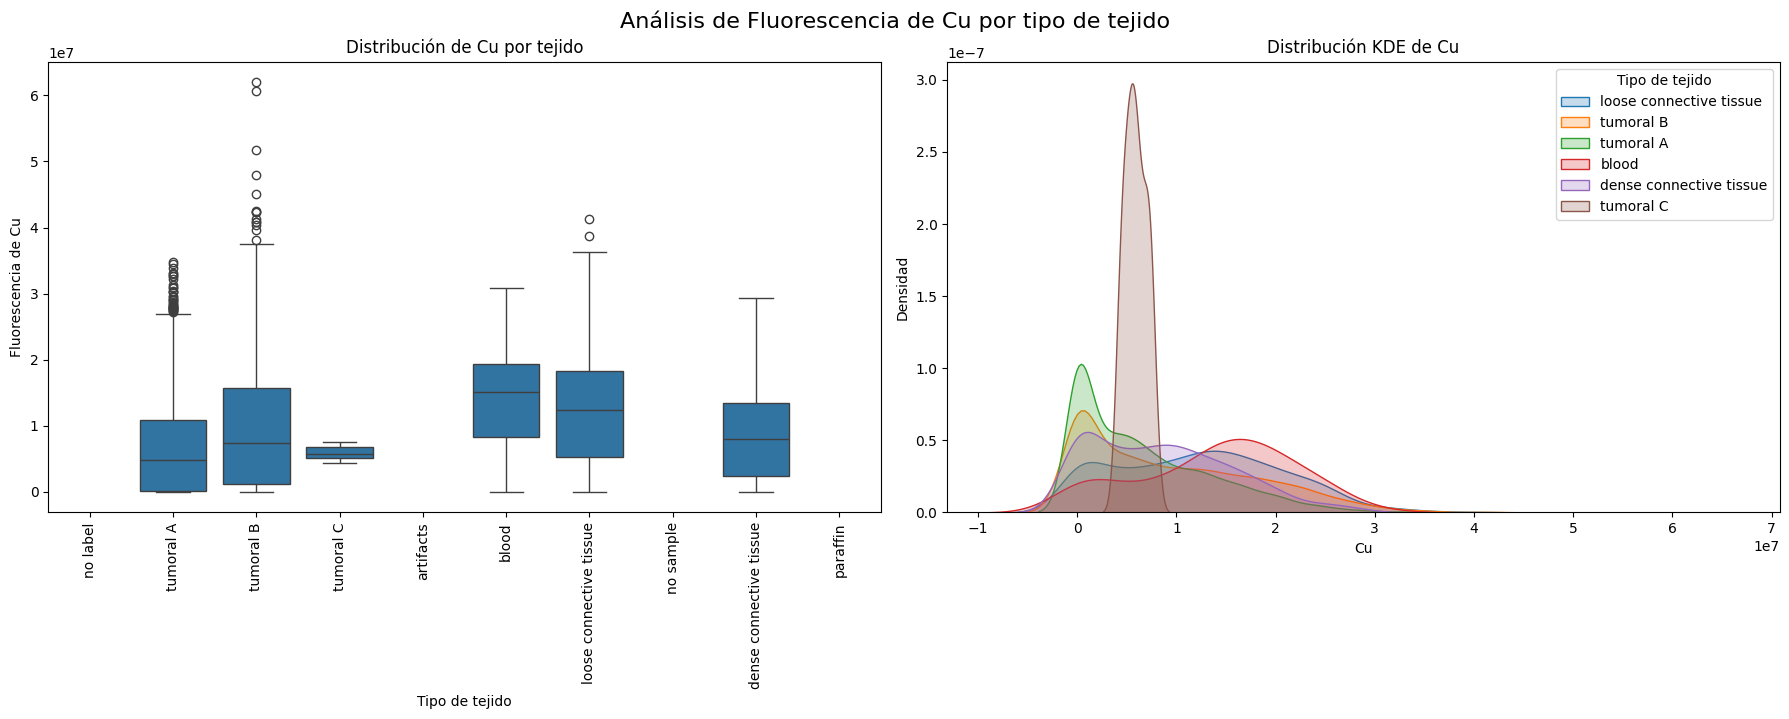

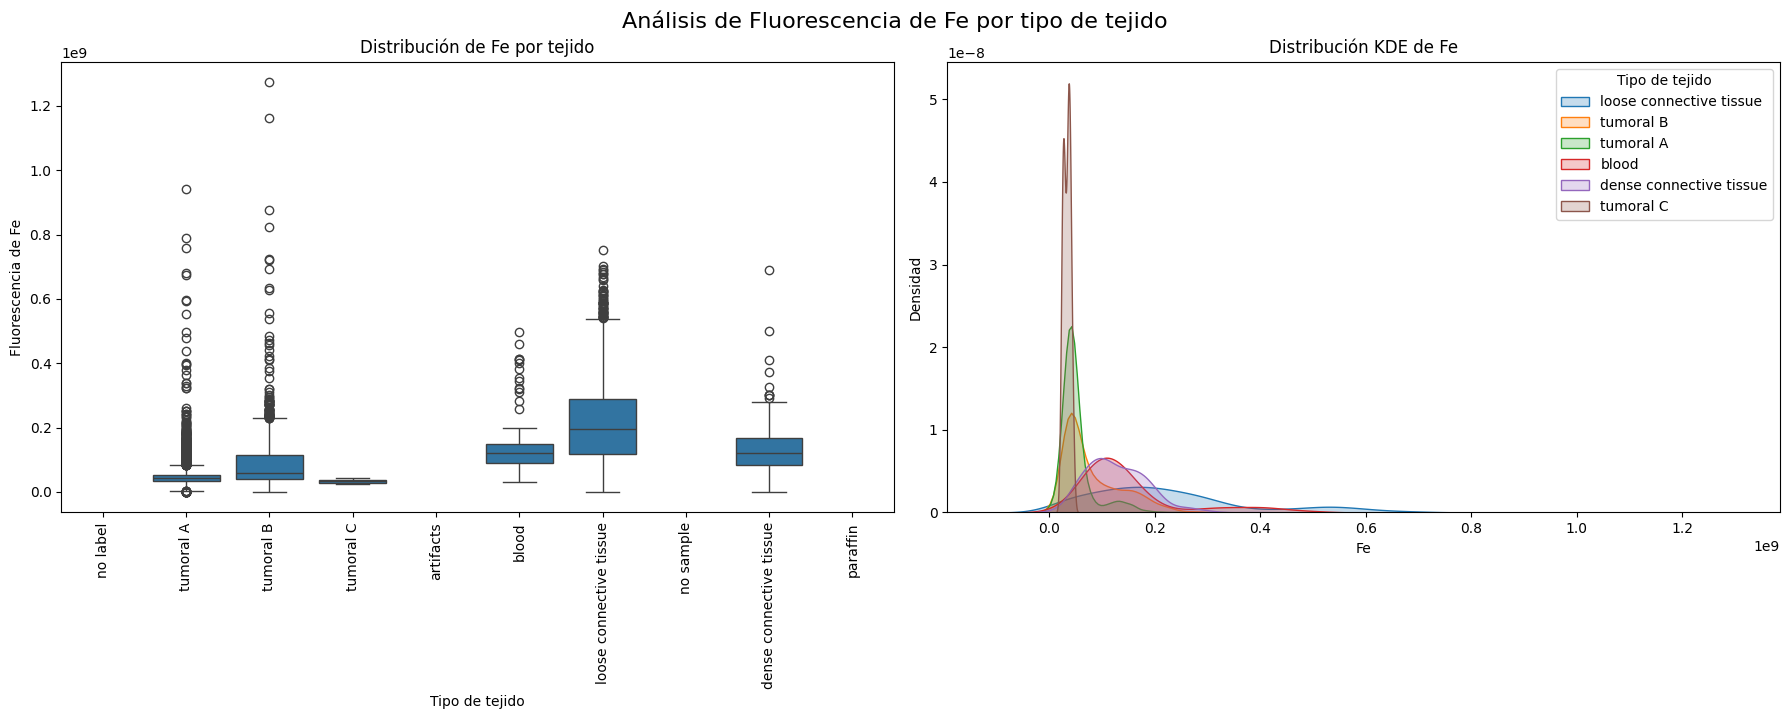

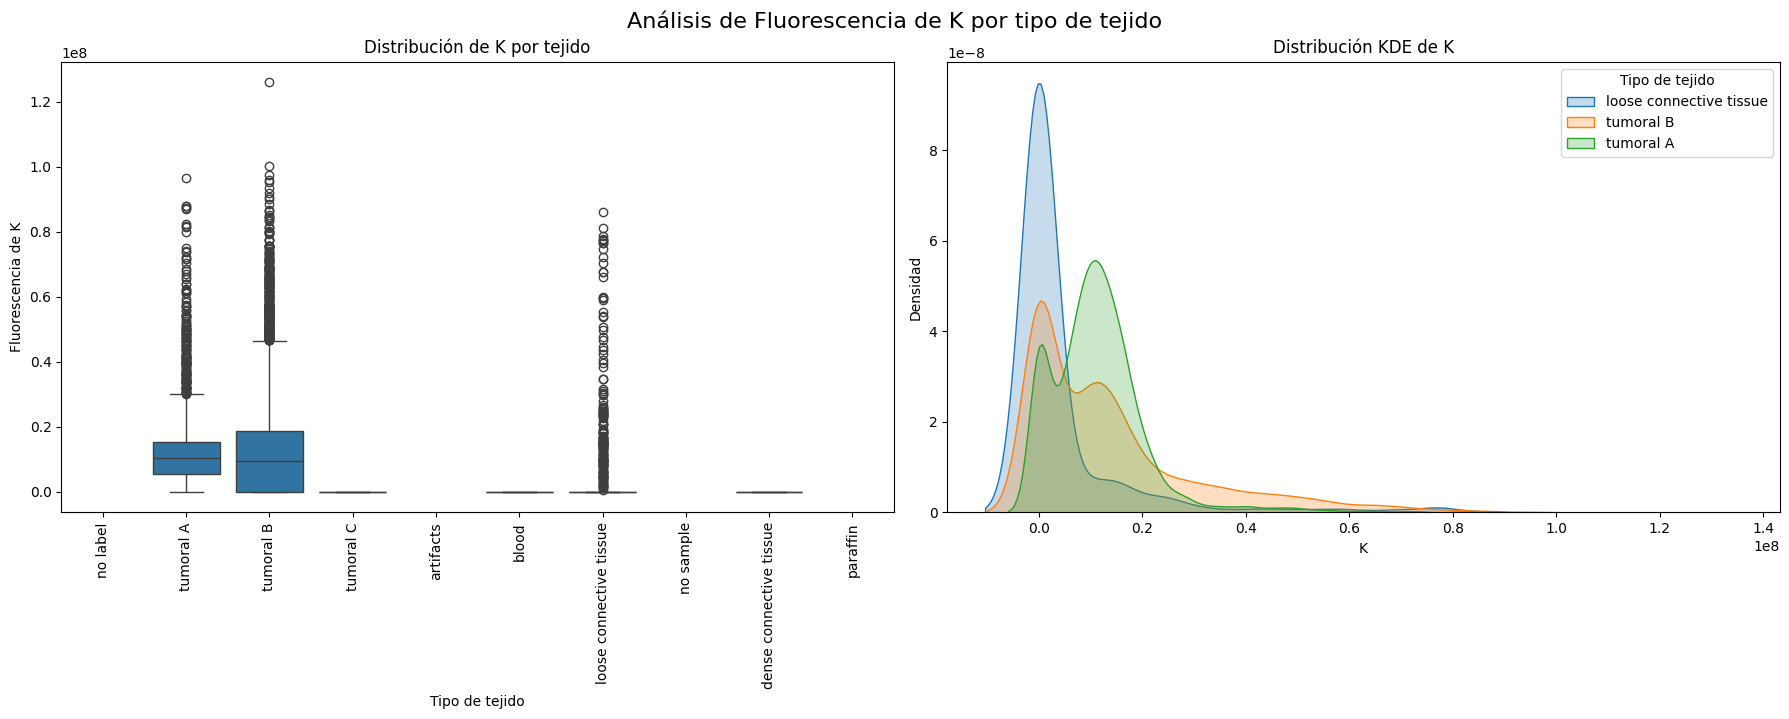

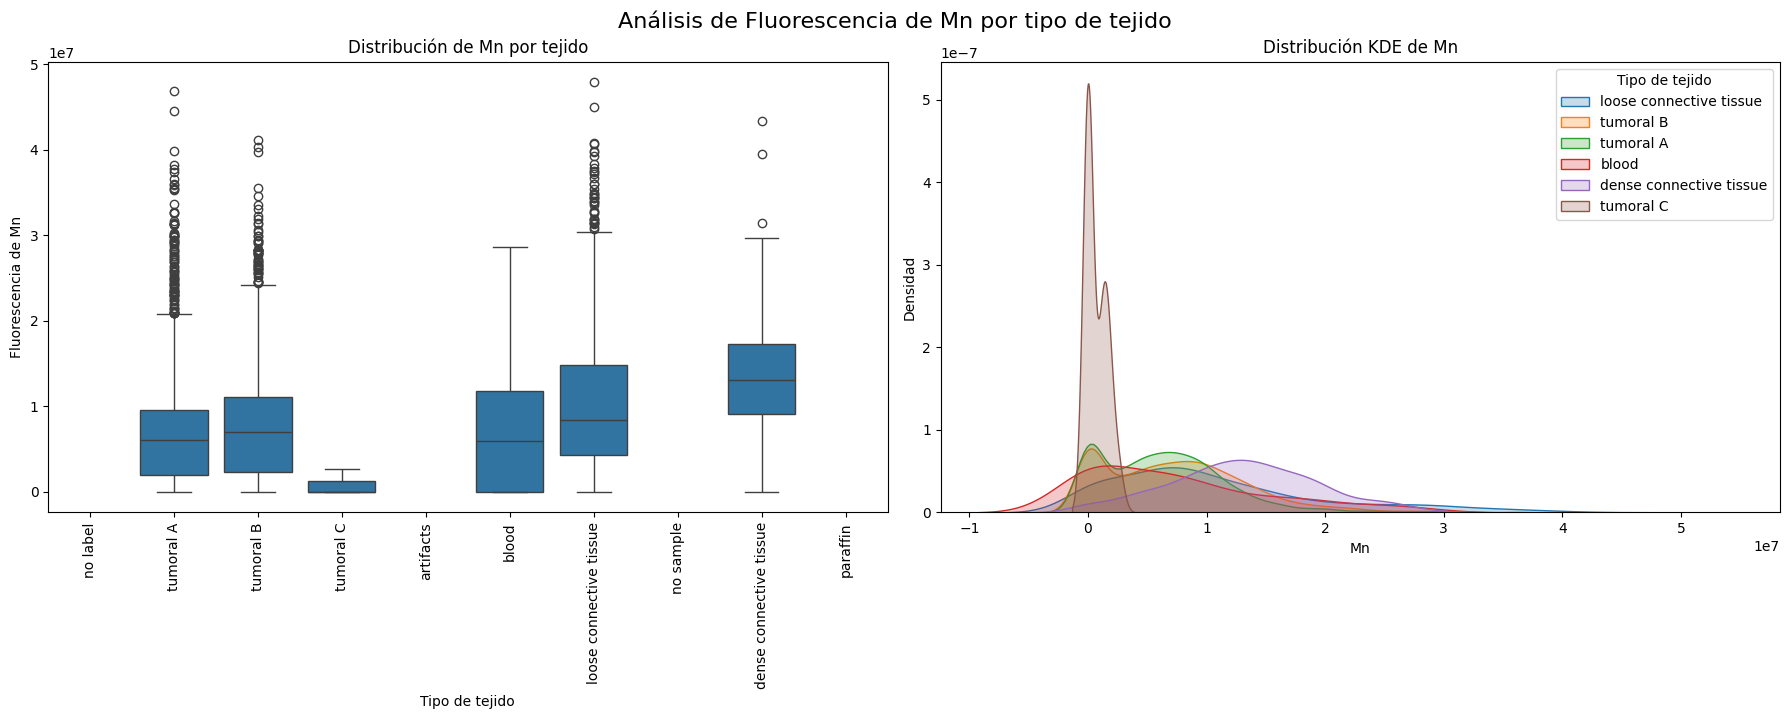

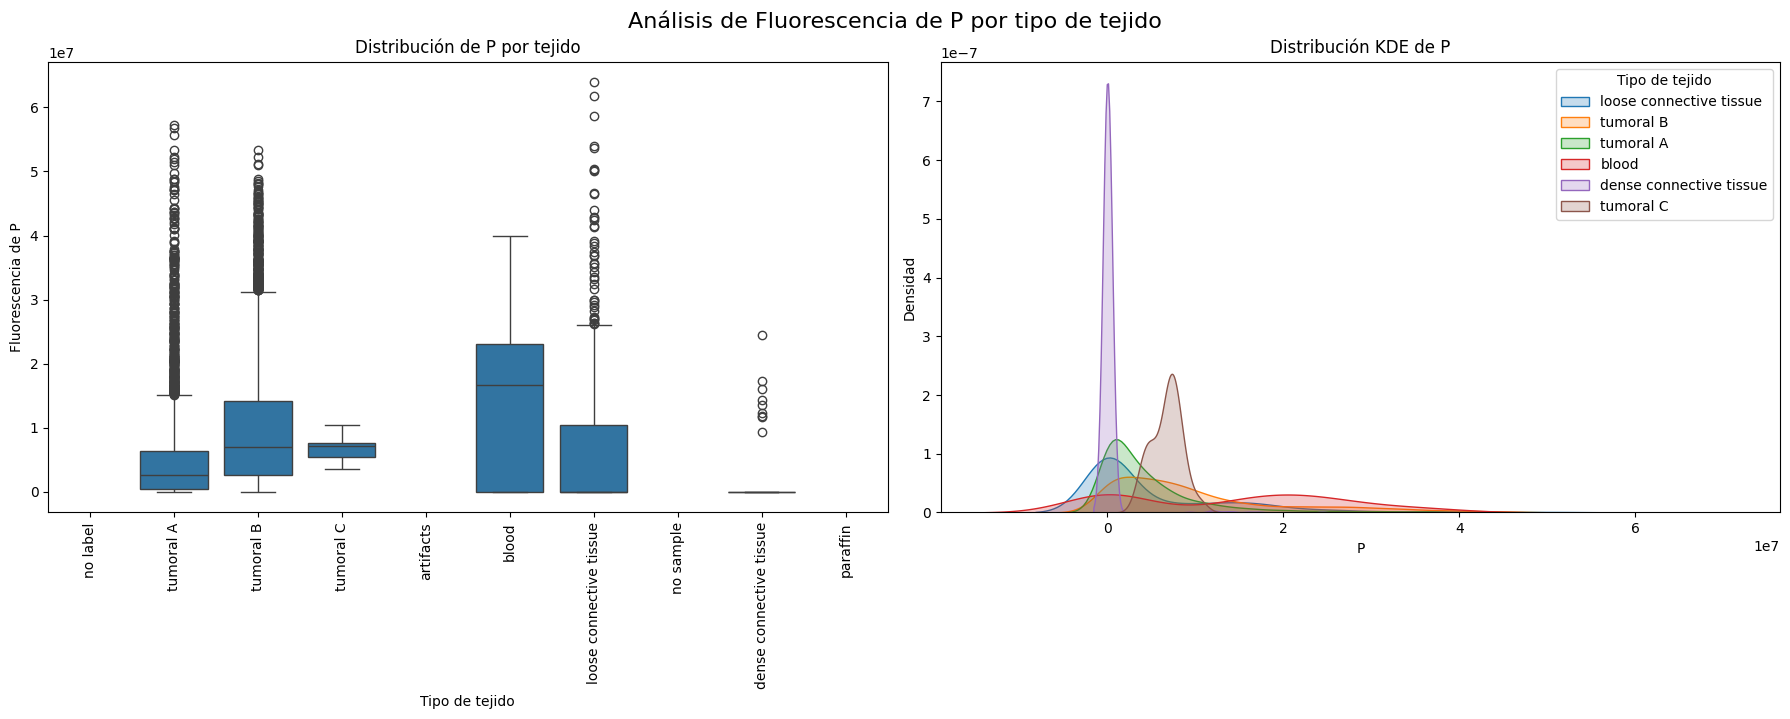

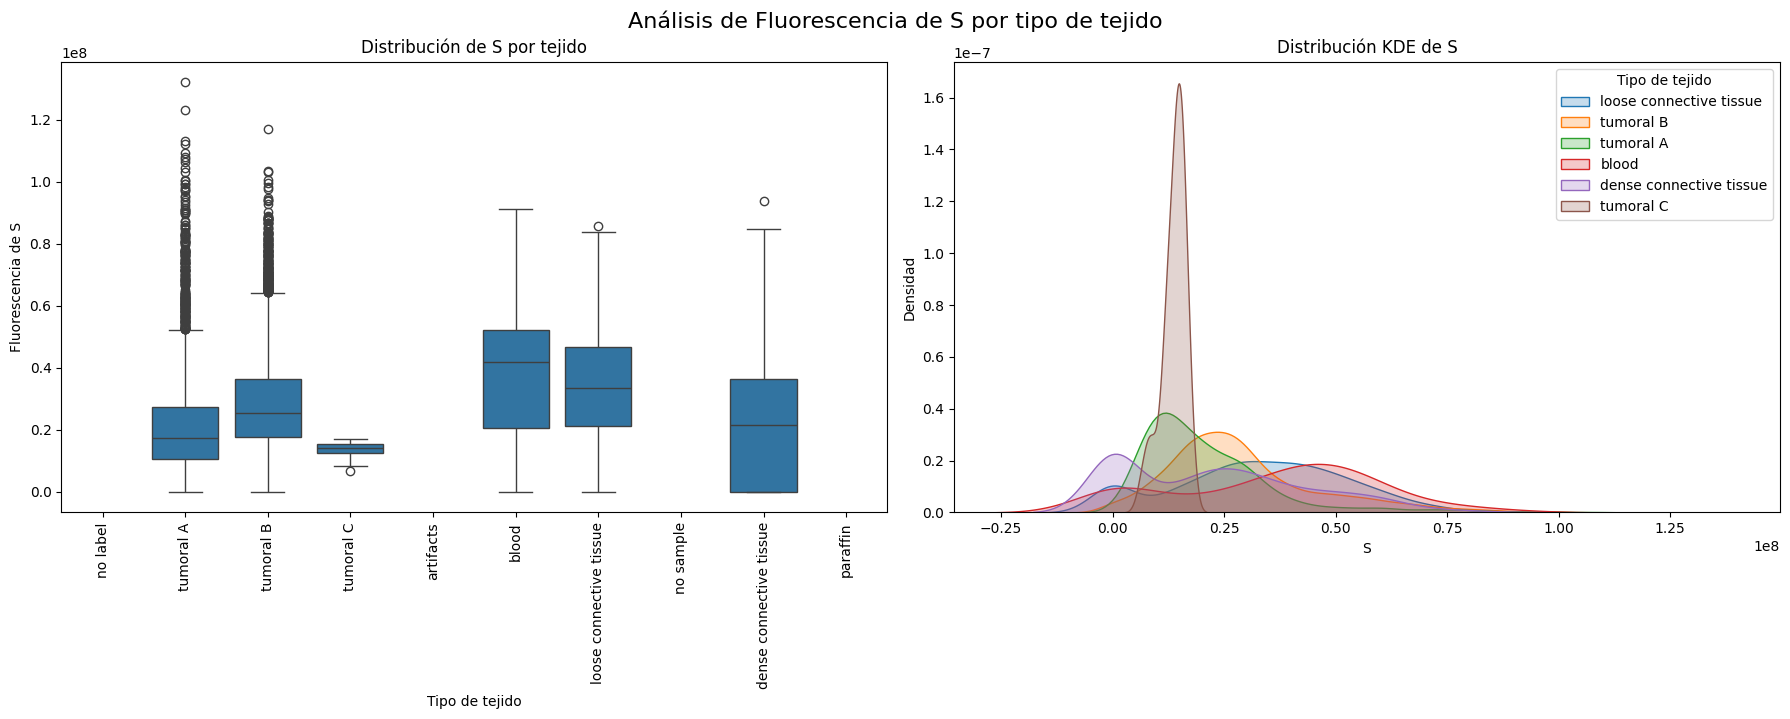

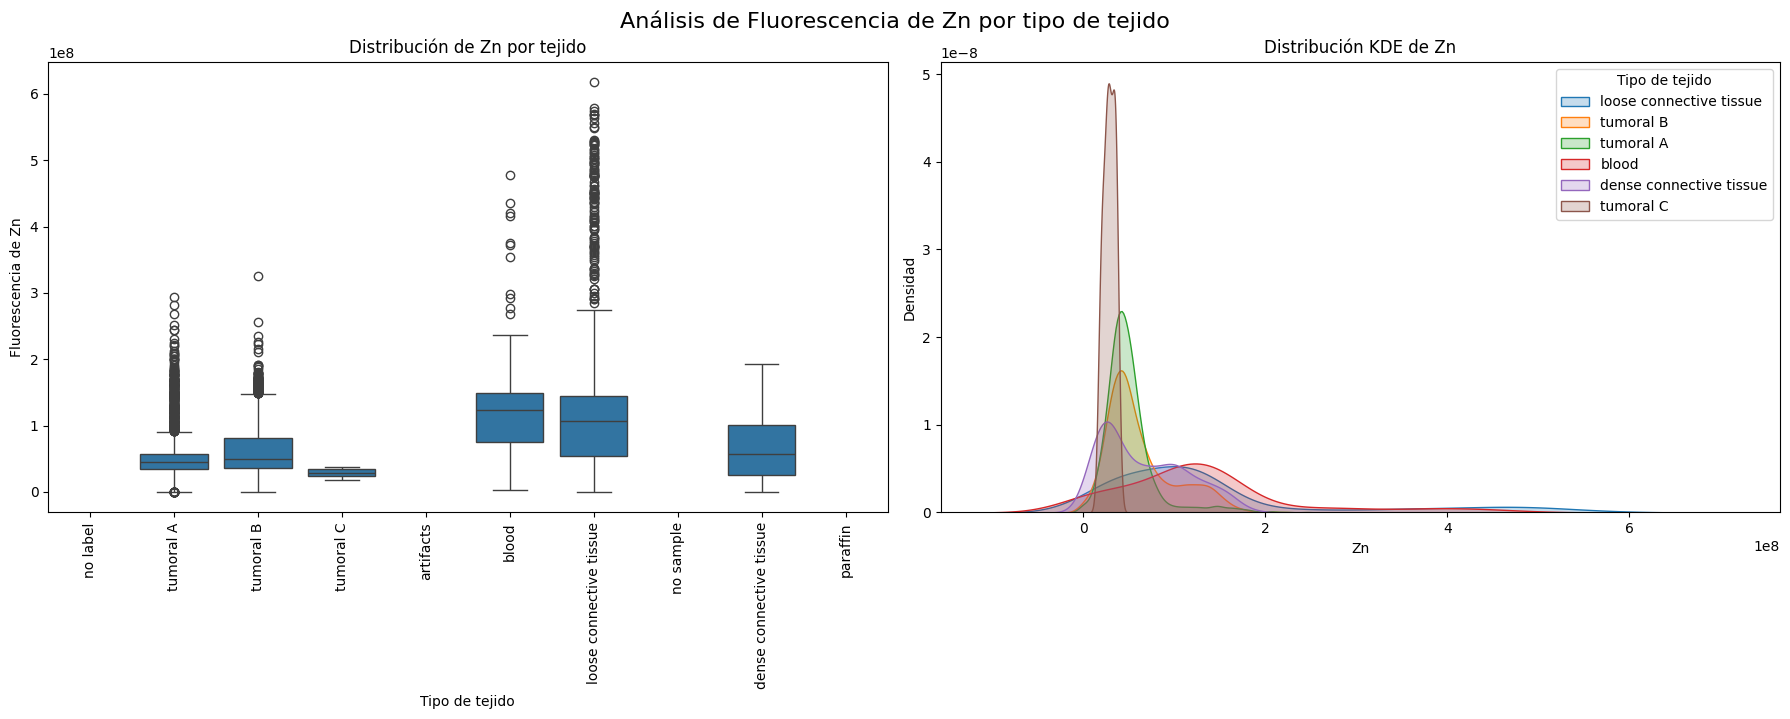

In [189]:
for element in fluorescence.element_order:
    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='label_name', y=element, data=df_tejido)
    plt.xticks(rotation=90)
    plt.title(f"Distribución de {element} por tejido")
    plt.xlabel('Tipo de tejido')
    plt.ylabel(f'Fluorescencia de {element}')

    plt.subplot(1, 2, 2)
    for label in df_tejido['label_name'].unique():
        sns.kdeplot(
            data=df_tejido[df_tejido['label_name'] == label],
            x=element, label=label, fill=True
        )
    plt.title(f'Distribución KDE de {element}')
    plt.xlabel(element)
    plt.ylabel('Densidad')
    plt.legend(title='Tipo de tejido')


    plt.tight_layout()
    plt.suptitle(f'Análisis de Fluorescencia de {element} por tipo de tejido', fontsize=16, y=1.02)
    plt.show()

Basandonos en las graficas de distribucion KDE, podemos observar rangos de intensidad donde ciertos elementos quimicos tienen una alta densidad de pixeles en diferentes tipos de tejido. Esto indica concentraciones frecuentes o predominantes en esos tejidos:

*   **Calcio (Ca):** Se observan picos de alta densidad en rangos elevados de fluorescencia para los tumores (tumoral C, tumoral A y tumoral B), indicando que muchos píxeles en estos tejidos tienen altas concentraciones de Calcio en comparación con otros elementos.
*   **Hierro (Fe):** Similar al Calcio, presenta picos de alta densidad en rangos altos para los tumores (tumoral C, tumoral A y tumoral B).
*   **Zinc (Zn):** Alta densidad de píxeles con concentraciones elevadas en los tumores (tumoral C, A y B), así como en "dense connective tissue".
*   **Azufre (S):** Se observa una notable diferencia en los rangos de alta densidad entre los tumores, siendo el tumor C el que presenta picos en intensidades más altas.
*   **Fósforo (P):** A diferencia de otros elementos, aquí se observa una mayor densidad de píxeles con concentraciones elevadas en "dense connective tissue", seguido por los tumores C y A.

## Fluorescencia media

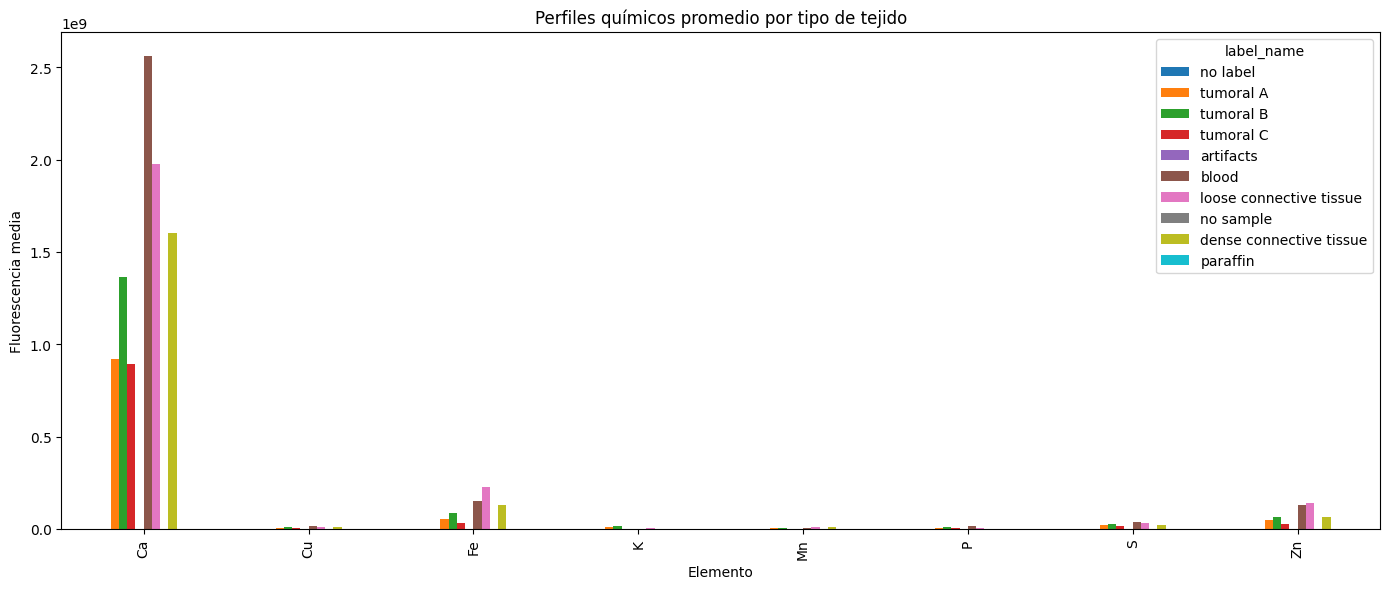

In [190]:
# Media por tejido
mean_profiles = df_tejido.groupby('label_name')[fluorescence.element_order].mean().T
mean_profiles.plot(kind='bar', figsize=(14, 6))
plt.title('Perfiles químicos promedio por tipo de tejido')
plt.ylabel('Fluorescencia media')
plt.xlabel('Elemento')
plt.tight_layout()
plt.show()

Los elementos con mayor presencia promedio son:
* **Ca (Calcio):** Muestra diferencias notables en la concentración promedio entre los tipos de tejido. Parece ser muy elevado en "blood" y "loose connective tissue", "dense connective tissue" y tumor B.
* **Fe (Hierro):** Es alto en "loose connective tissue", "blood", "dense connective tissue" y tumor B
* **Zn (Zinc):** Alto en "loose connective tissue", "blood" y "dense connective tissue".
* **S (Azufre):** Las concentraciones de Azufre también varían entre tejidos, con niveles elevados en los tejidos tumorales, "blood" y "loose connective tissue".

## Mapa de correlacion

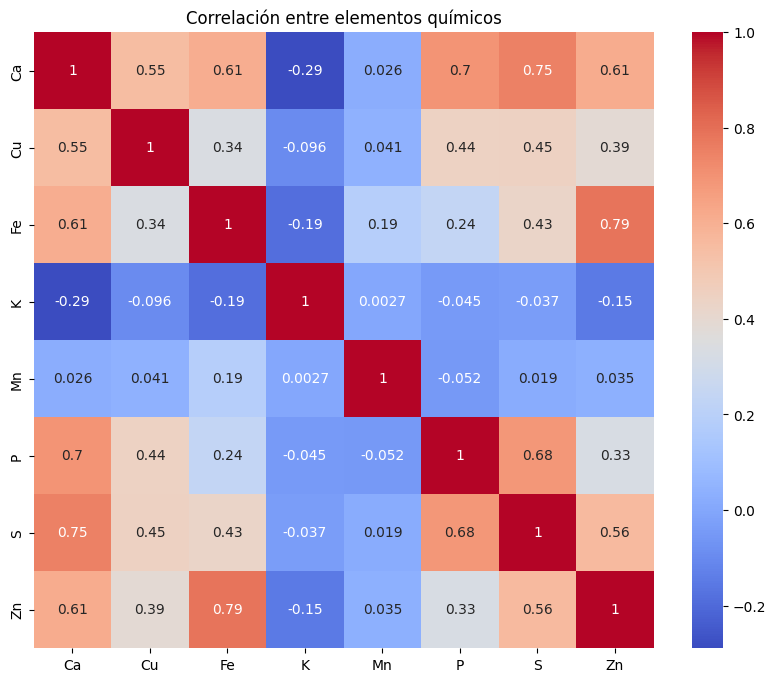

In [191]:
# Heatmap de correlación
corr = df_tejido[fluorescence.element_order].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlación entre elementos químicos")
plt.show()

Se observan correlaciones positivas importantes entre:
* Fe y Zn: 0.79
* Ca y S: 0.75
* Ca y P: 0.7
* P y S: 0.68
* Ca y Fe: 0.61
* Ca y Zn: 0.61
* S y Zn: 0.56
* Ca y Cu: 0.55

## Prueba de hipotesis

In [192]:
# T-tests entre tejidos
for var in fluorescence_cols:
    print(f"\nT-tests para {var} por tejido:")
    grupos = [df_tejido[df_tejido['label_name'] == l][var] for l in labels_interesting]
    for i in range(len(grupos)):
        for j in range(i + 1, len(grupos)):
            stat, pval = stats.ttest_ind(grupos[i], grupos[j], equal_var=False)
            res = "Rechaza H0" if pval < alpha else "No rechaza H0"
            print(f"{labels_interesting[i]} vs {labels_interesting[j]}: t={stat:.3f}, p={pval:.3e} → {res}")


T-tests para Ca por tejido:
necrotic tissue vs tumoral A: t=nan, p=nan → No rechaza H0
necrotic tissue vs tumoral B: t=nan, p=nan → No rechaza H0
necrotic tissue vs tumoral C: t=nan, p=nan → No rechaza H0
necrotic tissue vs blood: t=nan, p=nan → No rechaza H0
necrotic tissue vs loose connective tissue: t=nan, p=nan → No rechaza H0
necrotic tissue vs dense connective tissue: t=nan, p=nan → No rechaza H0
tumoral A vs tumoral B: t=-23.537, p=1.061e-117 → Rechaza H0
tumoral A vs tumoral C: t=0.972, p=3.386e-01 → No rechaza H0
tumoral A vs blood: t=-16.138, p=1.055e-29 → Rechaza H0
tumoral A vs loose connective tissue: t=-30.218, p=7.216e-141 → Rechaza H0
tumoral A vs dense connective tissue: t=-23.581, p=1.677e-91 → Rechaza H0
tumoral B vs tumoral C: t=14.566, p=1.803e-18 → Rechaza H0
tumoral B vs blood: t=-11.661, p=1.322e-20 → Rechaza H0
tumoral B vs loose connective tissue: t=-16.352, p=1.846e-54 → Rechaza H0
tumoral B vs dense connective tissue: t=-7.443, p=2.095e-13 → Rechaza H0
tumo

Observamos algunos NaN en "necrotic tissue", esto es porque no hay diferencia o no se puede calcular el valor de p porque no hay datos. Esto sugiere que este tejido no tiene datos medibles para ninguno de los elementos.

**Comparaciones entre tipos tumorales (A, B, C):**

* Para todos los elementos excepto algunos casos puntuales (por ejemplo, Ca entre A y C, K entre C y sangre, etc.), se rechaza la hipótesis nula, indicando diferencias significativas. Esto sugiere que existen diferencias claras en la concentración de elementos entre subtipos tumorales, reforzando la idea de heterogeneidad química dentro de la masa tumoral.

**Comparaciones tumorales vs tejidos no tumorales (sangre, conectivo):**

* La mayoría de los pares muestran rechazo de H0, confirmando que las concentraciones promedio de estos elementos en tejido tumoral difieren de las de la sangre y de los tejidos conectivos. Excepciones puntuales (ej: Mn y sangre, Zn y sangre) no muestran diferencias significativas, lo que sugiere que para ciertos elementos, los niveles pueden ser similares entre sangre y tumor.

**Comparaciones dentro de tejidos conectivos y sangre:**

* En general, los tejidos conectivos presentan diferencias estadísticamente significativas para la mayoría de los elementos. También aparecen diferencias entre sangre y conectivo denso, aunque no siempre entre sangre y conectivo suelto (por ejemplo, para Cu, S o Zn en algunos pares no se rechaza H0).

# Conclusion

En este estudio se analizaron detalladamente las distribuciones, correlaciones y diferencias estadisticas de la fluorescencia elemental en distintos tipos de tejido y dietas experimentales en ratones. Llegandose a las siguientes concliusiones:

* **Distribuciones y perfiles quimicos por tipo de tejido:**
Los análisis de distribución (KDE y boxplots) y los T-tests mostraron que Calcio (Ca), Hierro (Fe), Zinc (Zn) y Azufre (S) son los elementos con mayor presencia promedio y variabilidad entre los diferentes tipos de tejido, destacandose especialmente en tejidos tumorales y en tejido conectivo denso.
Se evidenciaron rangos de alta densidad para Ca, Fe y Zn en tumores (principalmente tumoral A, B y C) y para P y S en conectivo denso, indicando patrones de acumulación diferenciales.
Los valores faltantes (NaN) en necrotic tissue indicaron que este tejido no presentó datos validos o mediciones cuantificables para estos elementos, lo que limitaria la comparacion para este caso.

* **Combinaciones elementales y perfiles caracteristicos:** El análisis de correlación identificó patrones claros de co-ocurrencia. En tejidos, se destacan correlaciones fuertes como Fe-Zn (0.79), Ca-S (0.75) y Ca-P (0.70), sugiriendo perfiles elementales que tienden a presentarse juntos en determinados contextos tisulares. En dieta, correlaciones altas como Ca-Zn (0.80), P-S (0.75) y Ca-S (0.74) confirman que ciertos elementos co-varían significativamente, posiblemente reflejando rutas metabólicas o de absorcion compartidas.

* **Efecto de la dieta sobre la composicion elemental:** Los resultados confirmaron que la dieta de los ratones (control, omega-3, omega-6) tiene un efecto significativo sobre la composicion elemental. Todas las comparaciones por pares mediante T-tests mostraron diferencias significativas (rechazo de H0) para todos los elementos analizados, reforzando que tanto la suplementación con Omega-3 como Omega-6 modifican de forma diferencial la bioacumulacion de Ca, Cu, Fe, K, Mn, P, S y Zn en los tejidos evaluados

* **Visualizaciones y evidencia estadistica:** Los mapas de distribucion (KDE), boxplots y heatmaps de correlacion proporcionaron una visualizacion clara y complementaria de los resultados estadisticos, permitiendo identificar rangos de concentracion frecuente y asociaciones entre elementos de forma visual.